<a href="https://colab.research.google.com/github/prajapativipul-pv/GTU_Edunet_internship/blob/main/day6_11_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

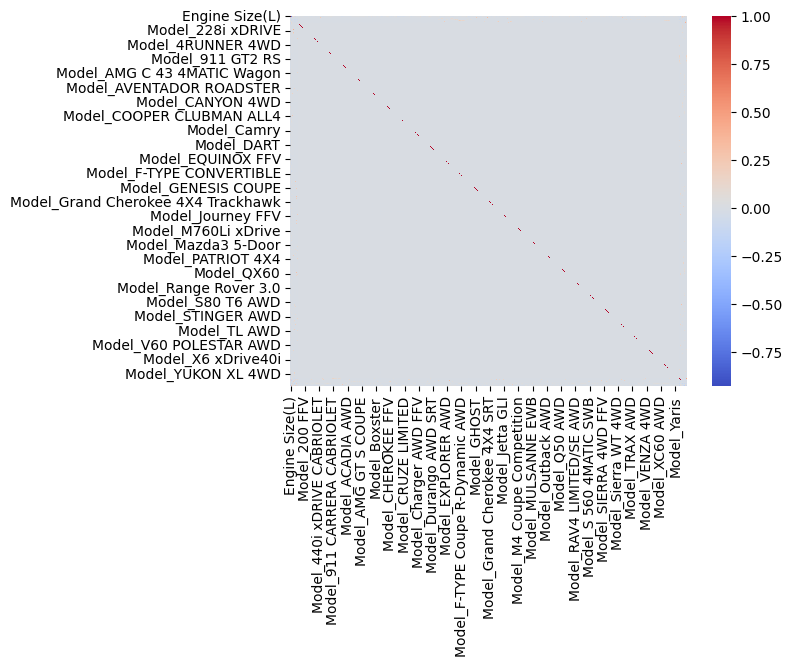

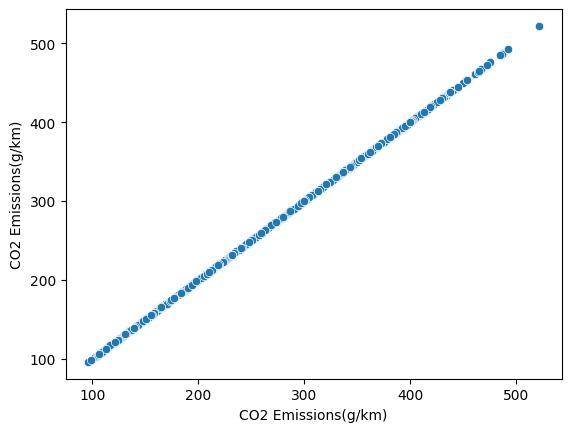

MAE: 3.685752815821973
MSE: 40.634439531248205
RMSE: 6.374514846735256
R2 Score: 0.9887399354936036


['2026-07-14_Linear_Regression.pkl']

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("CO2_Emissions.csv")

# First 5 rows
print(df.head())

# Dataset Information
print(df.info())
print(df.describe())

# Check Null Values
print(df.isnull().sum())

# Fill Numerical Null Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Relation between columns
# Energy consumption and population affect CO2 emissions.
# GDP also has relation with CO2 emissions.

# Encode categorical columns
df = pd.get_dummies(df, drop_first=True)

# Target Column
X = df.drop("CO2 Emissions(g/km)", axis=1)
y = df["CO2 Emissions(g/km)"]

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualization
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

sns.scatterplot(x=y, y=y)
plt.show()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Insights
# Missing values filled using mean.
# Dummy encoding used because categorical columns cannot be used directly.
# Scaling applied because features have different ranges.
# Linear Regression predicts CO2 emissions.

# Save Model
import joblib
joblib.dump(model, "2026-07-14_Linear_Regression.pkl")
